In [1]:
import pymysql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
conn=pymysql.connect(host='localhost',user='root',password='kousik@123',database='Banking Analysis 1',charset='utf8')
con=conn

In [3]:
dt=pd.read_sql("SELECT * FROM `Customer Information`",conn)
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   S.No                     73 non-null     int64  
 1   Customer Id              73 non-null     int64  
 2   Customer Name            73 non-null     str    
 3   Account Number           73 non-null     int64  
 4   Account Type             67 non-null     str    
 5   Account Status           73 non-null     str    
 6   Account Balance          56 non-null     float64
 7   Branch Name              62 non-null     str    
 8   Branch Code              67 non-null     float64
 9   Customer Age             73 non-null     int64  
 10  Customer Marital Status  72 non-null     str    
 11  Customer Location        65 non-null     str    
dtypes: float64(2), int64(4), str(6)
memory usage: 7.0 KB


C:\Users\acer\AppData\Local\Temp\ipykernel_15416\2987236909.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dt=pd.read_sql("SELECT * FROM `Customer Information`",conn)


In [4]:
dt.head()

,S.No,Customer Id,Customer Name,Account Number,Account Type,Account Status,Account Balance,Branch Name,Branch Code,Customer Age,Customer Marital Status,Customer Location
0,1,89011,Raja,784596651,Savings Account,Active,300000.0,TDPR,1111.0,28,Married,Cuddalore
1,1,89011,Raja,784596651,Savings Account,Active,300000.0,TDPR,1111.0,28,Married,Cuddalore
2,2,89012,Ramesh,647896651,Current Account,Active,4569877.0,TDPR,1111.0,35,Married,NaN
3,3,69215,Harini,884596651,Savings Account,Active,2456789.0,TDPR,1111.0,19,Unmarried,NaN
4,4,75908,Suresh,784598974,Savings Account,Active,895679.0,NaN,5555.0,29,Married,Cuddalore OT


In [5]:
dt.tail()

,S.No,Customer Id,Customer Name,Account Number,Account Type,Account Status,Account Balance,Branch Name,Branch Code,Customer Age,Customer Marital Status,Customer Location
68,47,39012,Kala,284566659,Savings Account,Inactive,1000.0,TDPR,1111.0,18,Unmarried,Cuddalore
69,48,29001,Kamala,284596000,Current Account,Active,120000.0,TDPR,1111.0,28,Married,Cuddalore
70,49,35111,Vignesh,424596001,Savings Account,Active,40000.0,TDPR,1111.0,48,Married,Cuddalore
71,50,20011,Kandha Samy,414596690,NaN,Inactive,55090.0,TDPR,1111.0,38,Married,Cuddalore
72,50,20011,Kandha Samy,414596690,NaN,Inactive,55090.0,TDPR,1111.0,38,Married,Cuddalore


In [6]:
dt.duplicated().sum()

np.int64(23)

In [7]:
dt=dt.drop_duplicates()
dt.duplicated().sum()

np.int64(0)

In [8]:
dt=dt.set_index(['S.No','Customer Id'])
dt.head()

,,Customer Name,Account Number,Account Type,Account Status,Account Balance,Branch Name,Branch Code,Customer Age,Customer Marital Status,Customer Location
S.No,Customer Id,,,,,,,,,,
1,89011,Raja,784596651,Savings Account,Active,300000.0,TDPR,1111.0,28,Married,Cuddalore
2,89012,Ramesh,647896651,Current Account,Active,4569877.0,TDPR,1111.0,35,Married,NaN
3,69215,Harini,884596651,Savings Account,Active,2456789.0,TDPR,1111.0,19,Unmarried,NaN
4,75908,Suresh,784598974,Savings Account,Active,895679.0,NaN,5555.0,29,Married,Cuddalore OT
5,53011,Kamalesh,584976651,Savings Account,Active,97467.0,MNJ,4545.0,17,Unmarried,Cuddalore MNJ


In [9]:
dt.isnull().sum()

Customer Name               0
Account Number              0
Account Type                4
Account Status              0
Account Balance            10
Branch Name                 5
Branch Code                 6
Customer Age                0
Customer Marital Status     1
Customer Location           7
dtype: int64

In [10]:
dt['Account Type'] = dt['Account Type'].fillna('Unknown')
dt['Account Balance'] = dt['Account Balance'].fillna('Unknown')
dt['Customer Marital Status'] = dt['Customer Marital Status'].fillna('Unknown')
dt.isnull().sum()

Customer Name              0
Account Number             0
Account Type               0
Account Status             0
Account Balance            0
Branch Name                5
Branch Code                6
Customer Age               0
Customer Marital Status    0
Customer Location          7
dtype: int64

In [11]:
dt.loc[(dt['Customer Location'] == 'Cuddalore') , 'Branch Name'] ='TDPR'
dt.loc[(dt['Customer Location'] == 'Cuddalore OT') , 'Branch Name'] ='CUPJ'
dt.loc[(dt['Customer Location'] == 'Cuddalore MNJ') , 'Branch Name'] ='MNJ'
dt.loc[(dt['Customer Location'] == 'Virudhachalam') , 'Branch Name'] ='VRCM'
dt.loc[(dt['Customer Location'] == 'Vaepur') , 'Branch Name'] ='VPR'
dt.isnull().sum()

Customer Name              0
Account Number             0
Account Type               0
Account Status             0
Account Balance            0
Branch Name                0
Branch Code                6
Customer Age               0
Customer Marital Status    0
Customer Location          7
dtype: int64

In [12]:
dt.loc[(dt['Branch Code'] == 1111) , 'Customer Location'] = 'Cuddalore'
dt.loc[(dt['Branch Code'] == 4545) , 'Customer Location'] = 'Cuddalore MNJ'
dt.loc[(dt['Branch Code'] == 5555) , 'Customer Location'] = 'Cuddalore OT'
dt.loc[(dt['Branch Code'] == 2222) , 'Customer Location'] = 'Vaepur'
dt.loc[(dt['Branch Code'] == 1001) , 'Customer Location'] = 'Virdhachalam'
dt.isnull().sum()

Customer Name              0
Account Number             0
Account Type               0
Account Status             0
Account Balance            0
Branch Name                0
Branch Code                6
Customer Age               0
Customer Marital Status    0
Customer Location          1
dtype: int64

In [13]:
dt.loc[(dt['Customer Location'] == 'Vaepur') , 'Branch Code'] = 2222
dt.loc[(dt['Customer Location'] == 'Virudhachalam') , 'Branch Code'] = 1001
dt.loc[(dt['Customer Location'] == 'Cuddalore') , 'Branch Code'] = 1111
dt.loc[(dt['Customer Location'] == 'Cuddalore OT') , 'Branch Code'] = 5555
dt.loc[(dt['Customer Location'] == 'Cuddalore MNJ') , 'Branch Code'] = 4545
dt.isnull().sum()

Customer Name              0
Account Number             0
Account Type               0
Account Status             0
Account Balance            0
Branch Name                0
Branch Code                1
Customer Age               0
Customer Marital Status    0
Customer Location          1
dtype: int64

In [14]:
dt.loc[(dt['Branch Name'] == 'TDPR') , 'Branch Code'] = 1111
dt.loc[(dt['Branch Code'] == 1111) , 'Customer Location'] = 'Cuddalore'
dt.isnull().sum()

Customer Name              0
Account Number             0
Account Type               0
Account Status             0
Account Balance            0
Branch Name                0
Branch Code                0
Customer Age               0
Customer Marital Status    0
Customer Location          0
dtype: int64

In [15]:
dt.dtypes
dt['Branch Code'] = dt['Branch Code'].astype('int64')

In [16]:
dt.info()

<class 'pandas.DataFrame'>
MultiIndex: 50 entries, (np.int64(1), np.int64(89011)) to (np.int64(50), np.int64(20011))
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Customer Name            50 non-null     str   
 1   Account Number           50 non-null     int64 
 2   Account Type             50 non-null     str   
 3   Account Status           50 non-null     str   
 4   Account Balance          50 non-null     object
 5   Branch Name              50 non-null     str   
 6   Branch Code              50 non-null     int64 
 7   Customer Age             50 non-null     int64 
 8   Customer Marital Status  50 non-null     str   
 9   Customer Location        50 non-null     str   
dtypes: int64(3), object(1), str(6)
memory usage: 4.9+ KB


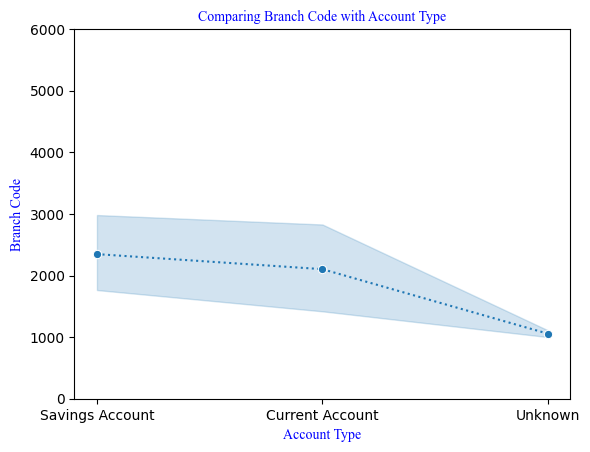

In [17]:
sns.lineplot(data=dt,x='Account Type',y='Branch Code',marker='o',linestyle=':')
plt.title('Comparing Branch Code with Account Type',color='Blue',font='Times New Roman')
plt.xlabel('Account Type',color='Blue',font='Times New Roman')
plt.ylabel('Branch Code',color='Blue',font='Times New Roman')
plt.ylim(0,6000)
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_15416\694518244.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dt,x='Customer Marital Status',palette='magma')


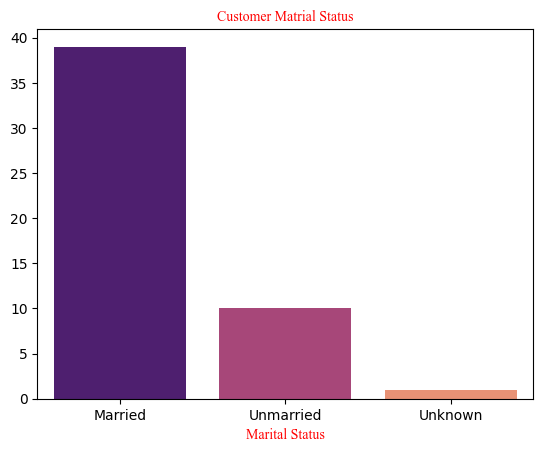

In [19]:
sns.countplot(data=dt,x='Customer Marital Status',palette='magma')
plt.title('Customer Matrial Status',color='Red',font='Times New Roman')
plt.xlabel('Marital Status',color='Red',font='Times New Roman')
plt.ylabel("")
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_15416\3118578729.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dt,x='Branch Name',y='Customer Age',palette=['Pink','Red','Cyan','Purple','Yellow'])


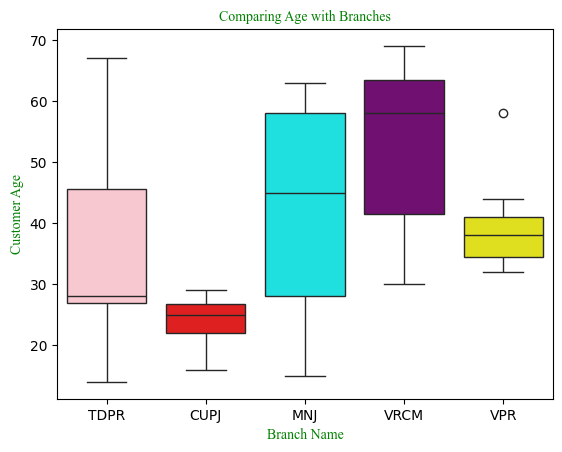

In [35]:
sns.boxplot(data=dt,x='Branch Name',y='Customer Age',palette=['Pink','Red','Cyan','Purple','Yellow'])
plt.title('Comparing Age with Branches',color='Green',font='Times New Roman')
plt.xlabel('Branch Name',color='Green',font='Times New Roman')
plt.ylabel('Customer Age',color='Green',font='Times New Roman')
plt.show()

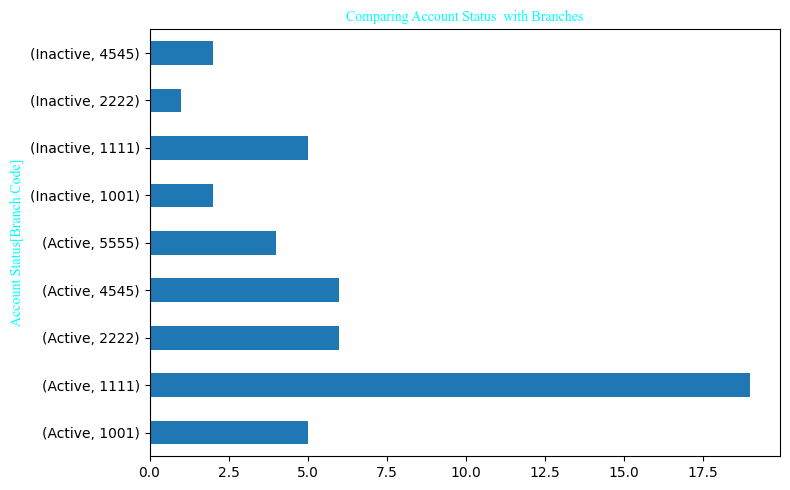

In [58]:
plt.figure(figsize=(8,5))
dt.groupby(['Account Status','Branch Code']).size().plot(kind='barh')
plt.title('Comparing Account Status  with Branches',color='Cyan',font='Times New Roman')
plt.ylabel('Account Status[Branch Code]',color='Cyan',font='Times New Roman')
plt.xlabel("")
plt.tight_layout()
plt.show()